<a href="https://colab.research.google.com/github/GunaSamhith/ML-labActivity/blob/main/8_6_1_SupportVectorMachines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import metrics
import seaborn as sns

data = pd.read_csv('/content/quadratic_svm_dataset.csv')

print(data.shape)
data.head()

(400, 3)


,X1,X2,Label
0,-1.255,-3.969,1
1,4.507,4.026,1
2,2.320,0.053,0
3,0.987,3.265,1
4,-3.440,-1.800,1


In [ ]:
data.isnull().sum()

,0
X1,0
X2,0
Label,0


In [ ]:
X = data[['X1', 'X2']]
y = data['Label']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=5
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (280, 2)
Testing data: (120, 2)


In [ ]:
model = SVC(kernel='rbf', random_state=0)

model.fit(x_train, y_train)

svm_prediction = model.predict(x_test)

print("SVM Prediction:")
print(svm_prediction)

SVM Prediction:
[1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 0 0 0 1 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 0 0
 0 1 0 1 1 1 0 1 0]


In [ ]:
conf_mat = metrics.confusion_matrix(y_test, svm_prediction)

print("SVM [kernel - rbf]")
print("Confusion Matrix:\n", conf_mat)

accuracy_score = metrics.accuracy_score(
    y_test,
    svm_prediction
)

print("Accuracy Score:", accuracy_score)
print("Accuracy in Percentage:", int(accuracy_score * 100), "%")

print("\nClassification Report:")
print(metrics.classification_report(y_test, svm_prediction))

SVM [kernel - rbf]
Confusion Matrix:
 [[27  2]
 [ 1 90]]
Accuracy Score: 0.975
Accuracy in Percentage: 97 %

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.95        29
           1       0.98      0.99      0.98        91

    accuracy                           0.97       120
   macro avg       0.97      0.96      0.97       120
weighted avg       0.97      0.97      0.97       120



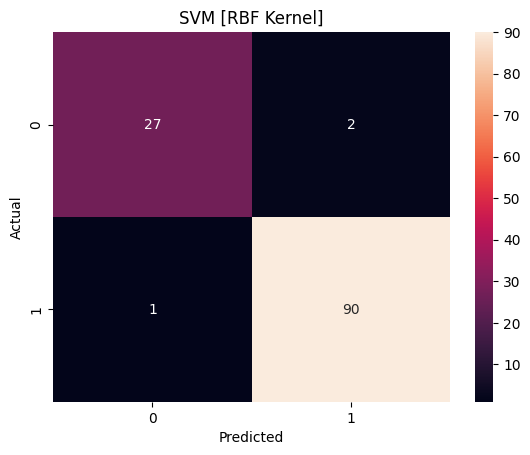

In [ ]:
conf_mat = pd.crosstab(
    y_test,
    svm_prediction,
    rownames=['Actual'],
    colnames=['Predicted']
)

sns.heatmap(conf_mat, annot=True, fmt='d')

plt.title('SVM [RBF Kernel]')
plt.show()

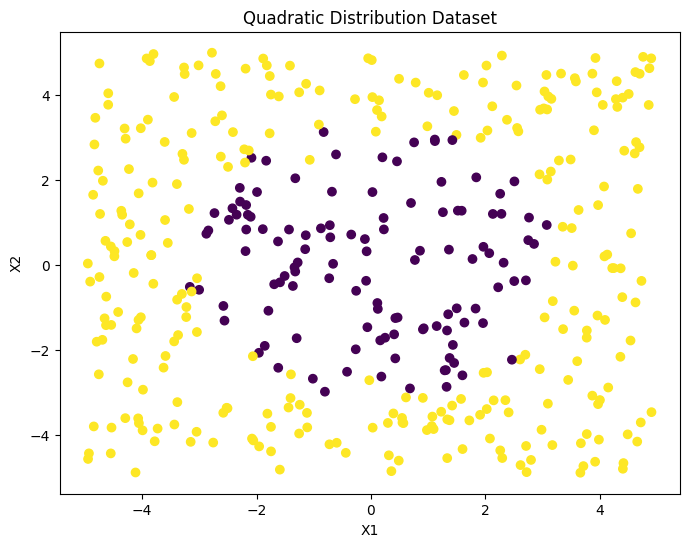

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    data['X1'],
    data['X2'],
    c=data['Label']
)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Quadratic Distribution Dataset')

plt.show()